In [2]:
import os
import numpy as np
import pandas as pd
import xarray as xr
from collections import defaultdict

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm
from scipy.stats import pearsonr
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as mticker

import calendar
import string
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind

from ARUtil import AROccurrenceFrequencyCalculator 


In [3]:
class AROccurrenceFrequencyPlotter:
    def __init__(self, data_dir, exp_dict, syear, eyear,
                 obs_label="ERA5", label_map=None, color_map=None):
        self.data_dir = data_dir
        self.exp_dict = exp_dict
        self.syear = syear
        self.eyear = eyear
        self.obs_label = obs_label
        self.label_map = label_map or exp_dict
        self.varname = "ar_frequency"
        self.metric_data = {}
        self.color_map = color_map or {}

    def normalize_lon(self, lon):
        lon_vals = lon.values if hasattr(lon, "values") else np.array(lon)
        return np.where(lon_vals > 180, lon_vals - 360, lon_vals)

    def get_and_normalize_longitude(self, ds):
        for lon_name in ['lon', 'longitude', 'LONG', 'x']:
            if lon_name in ds.coords:
                norm_lon = self.normalize_lon(ds[lon_name])
                ds = ds.assign_coords({lon_name: norm_lon})
                ds = ds.sortby(lon_name)
                if lon_name != 'lon':
                    ds = ds.rename({lon_name: 'lon'})
                return ds
        print("[WARN] No recognized longitude coordinate found.")
        return ds

    def compute_pattern_corr_exclude_zeros(self, da1, da2):
        arr1 = da1.values.flatten()
        arr2 = da2.values.flatten()
        mask = np.isfinite(arr1) & np.isfinite(arr2) & (arr1 != 0)
        if np.sum(mask) < 2:
            return np.nan
        return pearsonr(arr1[mask], arr2[mask])[0]

    def compute_rmse(self, da1, da2):
        arr1 = da1.values.flatten()
        arr2 = da2.values.flatten()
        mask = np.isfinite(arr1) & np.isfinite(arr2) & (arr1 != 0)
        if np.sum(mask) < 2:
            return np.nan
        return np.sqrt(np.mean((arr1[mask] - arr2[mask]) ** 2))
    
    def load_monthly_climatology(self, return_percent=True):
        """Return monthly climatology of AR occurrence: either percent or raw AR days."""
        all_labels = [self.obs_label] + list(self.exp_dict)
        monthly_data = {}

        for label in all_labels:
            monthly_list = []
            for year in range(self.syear, self.eyear + 1):
                fname = f"{label}_AR_frequency_{year}.nc"
                fpath = os.path.join(self.data_dir, label, fname)
                if not os.path.exists(fpath):
                    print(f"[WARN] Missing file: {fpath}")
                    continue
                try:
                    ds = xr.open_dataset(fpath)
                    ds = self.get_and_normalize_longitude(ds)

                    if 'monthly_ar_days' in ds:
                        var_da = ds['monthly_ar_days']
                        if "year" not in var_da.dims:
                            var_da = var_da.expand_dims(year=[year])

                        if return_percent:
                            # Convert to % using 6-hourly steps per month (~4/day)
                            month_lengths = np.array([31,28,31,30,31,30,31,31,30,31,30,31])
                            steps_per_day = 4
                            steps_per_month = month_lengths * steps_per_day
                            steps_da = xr.DataArray(
                                steps_per_month,
                                dims=["month"],
                                coords={"month": var_da["month"]}
                            )
                            var_da = (var_da / steps_da) * 100.0
                            var_da.name = "monthly_ar_percent"
                            var_da.attrs.update({
                                "description": "Monthly AR frequency as percent of 6-hourly steps",
                                "units": "%",
                                "computed_from": "monthly_ar_days / time_steps × 100"
                            })
                        else:
                            var_da.name = "monthly_ar_days"
                            var_da.attrs.update({
                                "description": "Monthly AR days",
                                "units": "AR days/month",
                                "computed_from": "monthly_ar_days"
                            })

                        monthly_list.append(var_da)
                except Exception as e:
                    print(f"[ERROR] Reading {fpath}: {e}")
                    continue

            if monthly_list:
                da = xr.concat(monthly_list, dim='year').mean(dim='year')
                monthly_data[label] = da
                print(f"[INFO] Loaded {len(monthly_list)} years for {label}")
            else:
                monthly_data[label] = None

        return monthly_data

    def load_and_compute_climatology(self):
        all_labels = [self.obs_label] + list(self.exp_dict)
        metric_data = {}

        for label in all_labels:
            yearly_data = []
            for year in range(self.syear, self.eyear + 1):
                fname = f"{label}_AR_frequency_{year}.nc"
                fpath = os.path.join(self.data_dir, label, fname)
                if not os.path.exists(fpath):
                    print(f"[WARN] Missing file: {fpath}")
                    continue
                try:
                    ds = xr.open_dataset(fpath)
                    ds = self.get_and_normalize_longitude(ds)
                    if 'monthly_ar_days' in ds:
                        # Sum over months to get total AR days/year
                        var_da = ds['monthly_ar_days'].sum(dim='month')
                        var_da = var_da.expand_dims(year=[year])
                        yearly_data.append(var_da)
                except Exception as e:
                    print(f"[ERROR] Reading {fpath}: {e}")
                    continue

            if yearly_data:
                da = xr.concat(yearly_data, dim='year').mean(dim='year')
                da.name = "annual_ar_days"
                da.attrs.update({
                    "description": "Climatological annual mean of AR days",
                    "units": "days/year",
                    "computed_from": "monthly_ar_days"
                })
                metric_data[label] = da
                print(f"[INFO] Loaded {len(yearly_data)} years for {label}")
            else:
                metric_data[label] = None

        return metric_data

    def compute_significance_mask(self, model_label, varname="monthly_ar_days", significance_level=0.05):
        """
        Compute a significance mask (boolean array) using a two-sample t-test
        comparing annual AR days between the model and the reference (obs_label).
        Returns a DataArray with True where difference is significant.
        """
        ref_yrs = []
        model_yrs = []

        for year in range(self.syear, self.eyear + 1):
            fpath_ref = os.path.join(self.data_dir, self.obs_label, f"{self.obs_label}_AR_frequency_{year}.nc")
            fpath_model = os.path.join(self.data_dir, model_label, f"{model_label}_AR_frequency_{year}.nc")

            if not os.path.exists(fpath_ref) or not os.path.exists(fpath_model):
                continue
            try:
                ds_ref = xr.open_dataset(fpath_ref)
                ds_model = xr.open_dataset(fpath_model)

                ref_yrs.append(ds_ref[varname].sum('month'))
                model_yrs.append(ds_model[varname].sum('month'))
            except Exception as e:
                print(f"[ERROR] Reading {year} for significance test: {e}")
                continue

        if not ref_yrs or not model_yrs:
            print(f"[WARN] Not enough data to compute significance mask for {model_label}")
            return None

        ref_stack = xr.concat(ref_yrs, dim='year')
        model_stack = xr.concat(model_yrs, dim='year')
        ref_stack = self.get_and_normalize_longitude(ref_stack)
        model_stack = self.get_and_normalize_longitude(model_stack)

        if ref_stack.shape != model_stack.shape:
            print(f"[WARN] Shape mismatch between reference and {model_label} for t-test")
            return None

        # Compute p-values using t-test
        t_stat, p_val = ttest_ind(model_stack.values, ref_stack.values, axis=0, equal_var=False, nan_policy='omit')
        sig_mask = (p_val < significance_level)
        sig_mask = np.where(np.isnan(sig_mask), False, sig_mask)

        # Wrap in 2D DataArray using lat/lon only
        lat = ref_stack.coords["lat"]
        lon = ref_stack.coords["lon"]
        return xr.DataArray(sig_mask, coords={"lat": lat, "lon": lon}, dims=("lat", "lon"))
    
    def plot(self,
             cmap_raw="YlGnBu",
             clevels_raw=None,
             cticks_raw=None,
             cmap_bias="RdBu_r",
             clevels_bias=None,
             cticks_bias=None,
             figsize=(14, 10),
             save_path=None,
             fontz=14,
             hspace=0.2,
             wspace=0.15):
        self.metric_data = self.load_and_compute_climatology()
        self.model_labels = [exp for exp in self.exp_dict if exp != self.obs_label]
        all_labels = [self.obs_label] + self.model_labels

        n_models = len(self.model_labels)
        ncols = 2
        nrows = 1 + int(np.ceil(n_models / ncols))

        fig = plt.figure(figsize=figsize)
        spec = gridspec.GridSpec(nrows=nrows, ncols=ncols, hspace=hspace, wspace=wspace)

        axs = []
        axs.append((self.obs_label, fig.add_subplot(spec[0, :], projection=ccrs.PlateCarree())))
        for i, label in enumerate(self.model_labels):
            row = 1 + (i // ncols)
            col = i % ncols
            axs.append((label, fig.add_subplot(spec[row, col], projection=ccrs.PlateCarree())))

        mesh_raw, mesh_bias = None, None
        norm_raw = BoundaryNorm(clevels_raw, plt.get_cmap(cmap_raw).N, extend='both') if clevels_raw is not None else None
        norm_bias = BoundaryNorm(clevels_bias, plt.get_cmap(cmap_bias).N, extend='both') if clevels_bias is not None else None

        for idx, (label, ax) in enumerate(axs):
            da = self.metric_data.get(label, None)

            if da is None:
                ax.axis("off")
                continue

            ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
            ax.coastlines()
            gl = ax.gridlines(draw_labels=True, linewidth=0.2, linestyle='--', alpha=0.6)
            gl.top_labels = gl.right_labels = False
            gl.xlabel_style = gl.ylabel_style = {'size': fontz}

            if idx == 0:
                mesh_raw = ax.pcolormesh(da.lon, da.lat, da, transform=ccrs.PlateCarree(),
                                         cmap=cmap_raw, norm=norm_raw, shading="auto")
                ax.set_title(f"(a) {self.label_map.get(label, label)}", fontsize=fontz, loc='left')
            else:
                ref = self.metric_data.get(self.obs_label)
                if ref is None or ref.shape != da.shape:
                    ax.axis("off")
                    continue

                bias = da - ref
                mesh_bias = ax.pcolormesh(bias.lon, bias.lat, bias, transform=ccrs.PlateCarree(),
                                          cmap=cmap_bias, norm=norm_bias, shading="auto")

                # === Significance test overlay ===
                sig_mask = self.compute_significance_mask(model_label=label)
                if sig_mask is not None:
                    ax.contourf(sig_mask.lon, sig_mask.lat, sig_mask, levels=[0.5, 1.5],
                                hatches=['...', None], colors='none', transform=ccrs.PlateCarree())

                # === Annotation
                panel_label = f"({chr(97 + idx)})"
                ax.set_title(f"{panel_label} {self.label_map.get(label, label)}", fontsize=fontz, loc='left')
                corr = self.compute_pattern_corr_exclude_zeros(ref, da)
                rmse = self.compute_rmse(ref, da)
                text = f"PCC: {corr:.2f}\nRMSE: {rmse:.2f}"
                ax.text(0.82, 0.85, text, transform=ax.transAxes, fontsize=fontz,
                        ha='right', va='center',
                        bbox=dict(facecolor='white', alpha=1.0, edgecolor='gray', boxstyle='round,pad=0.2'))

        if mesh_raw is not None:
            cax1 = fig.add_axes([0.72, 0.66, 0.015, 0.22])
            cbar1 = plt.colorbar(mesh_raw, cax=cax1, orientation="vertical")
            cbar1.set_label("AR Days (per year)", fontsize=fontz)
            if cticks_raw is not None:
                cbar1.set_ticks(cticks_raw)
            cbar1.ax.tick_params(labelsize=fontz)

        if mesh_bias is not None:
            cax2 = fig.add_axes([0.92, 0.12, 0.015, 0.45])
            cbar2 = plt.colorbar(mesh_bias, cax=cax2, orientation="vertical")
            cbar2.set_label("Bias (Model - ERA5)", fontsize=fontz)
            if cticks_bias is not None:
                cbar2.set_ticks(cticks_bias)
            cbar2.ax.tick_params(labelsize=fontz - 2)

        if save_path:
            plt.savefig(save_path, dpi=600, bbox_inches='tight')
            print(f"[SAVED] {save_path}")
        plt.show()
        plt.close()

    def _subset_region(self, da, lat1, lat2, lon1, lon2):
        """Subset a DataArray over a lat/lon box with automatic longitude normalization."""
        da = da.sel(lat=slice(lat1, lat2))

        lon = da.lon
        if lon.max() > 180:
            lon1_mod = lon1 % 360
            lon2_mod = lon2 % 360
        else:
            lon1_mod = ((lon1 + 180) % 360) - 180
            lon2_mod = ((lon2 + 180) % 360) - 180

        da = da.assign_coords(lon=da.lon)
        if lon1_mod < lon2_mod:
            da = da.sel(lon=slice(lon1_mod, lon2_mod))
        else:
            da = da.where((da.lon >= lon1_mod) | (da.lon <= lon2_mod), drop=True)

        return da
    
    def plot_annual_cycle_by_basin(self, region_dict=None, return_percent=True,
                                    fontz=12, figsize=(16, 10), save_path=None):
        """
        Plot annual cycle of AR frequency or days over selected AR basins using unified exp_config.
        """
        region_dict = region_dict or {
            "NE Pacific":     (20, 60, 180, 240),
            "North Atlantic": (20, 60, 270, 330),
            "South Pacific":  (-60, -20, 160, 240),
            "South Atlantic": (-60, -20, 300, 360),
            "South Indian":   (-50, -20, 40, 120)
        }

        monthly_data = self.load_monthly_climatology(return_percent=return_percent)
        ylabel = "AR Frequency (% per month)" if return_percent else "AR Days per Month"

        panel_labels = list(string.ascii_lowercase)
        month_ticks = list(range(1, 13))
        month_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

        n_panels = len(region_dict)
        ncols = 3 if n_panels > 3 else n_panels
        nrows = int(np.ceil(n_panels / ncols))


        fig, axs = plt.subplots(nrows, ncols, figsize=figsize)  # No constrained_layout
        
        axs = axs.flatten() if n_panels > 1 else [axs]
        
        for i, (region_name, bounds) in enumerate(region_dict.items()):
            ax = axs[i]
            ax.set_title(f"({panel_labels[i]}) {region_name}", fontsize=fontz, loc="left")

            lat1, lat2, lon1, lon2 = bounds

            # === Reference
            da_ref = monthly_data.get(self.obs_label)
            reg_mean_ref = None
            if da_ref is not None and "month" in da_ref.dims:
                reg_da = self._subset_region(da_ref, lat1, lat2, lon1, lon2)
                reg_mean_ref = reg_da.mean(dim=("lat", "lon"), skipna=True)
                ref_label = self.exp_dict[self.obs_label]["label"]
                ref_color = self.exp_dict[self.obs_label]["color"]
                ax.bar(month_ticks, reg_mean_ref, label=ref_label, color=ref_color,
                       alpha=0.6, width=0.7, edgecolor='k', zorder=2)

            # === Models
            for exp in self.exp_dict:
                if exp == self.obs_label:
                    continue

                da = monthly_data.get(exp)
                if da is None or "month" not in da.dims:
                    continue

                reg_da = self._subset_region(da, lat1, lat2, lon1, lon2)
                reg_mean = reg_da.mean(dim=("lat", "lon"), skipna=True)

                exp_label = self.exp_dict[exp]["label"]
                exp_color = self.exp_dict[exp]["color"]
                ax.plot(month_ticks, reg_mean, label=exp_label, color=exp_color,
                        linewidth=1.8, zorder=3)

            ax.set_xticks(month_ticks)
            ax.set_xticklabels(month_labels, fontsize=fontz)
            ax.set_xlabel("Month", fontsize=fontz)
            ax.set_ylabel(ylabel, fontsize=fontz)
            ax.tick_params(labelsize=fontz - 1)
            ax.grid(True, linestyle='--', alpha=0.5)
            ax.set_ylim(bottom=0)
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

        # Turn off unused subplots
        for ax in axs[n_panels:]:
            ax.axis('off')
            
        plt.subplots_adjust(hspace=0.35, wspace=0.25)  # Adjust spacing

        # Legend
        handles, labels = axs[0].get_legend_handles_labels()
        if labels:
            fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.04),
                       ncol=len(labels), fontsize=fontz)

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"[SAVED] {save_path}")

        plt.show()


[INFO] Loaded 10 years for ERA5
[INFO] Loaded 10 years for ERA5
[INFO] Loaded 10 years for CLIM
[INFO] Loaded 10 years for NDGUV
[INFO] Loaded 10 years for NDGUVT
[INFO] Loaded 10 years for NDGUVTQ_SRF1
[SAVED] ./Figure_11.pdf


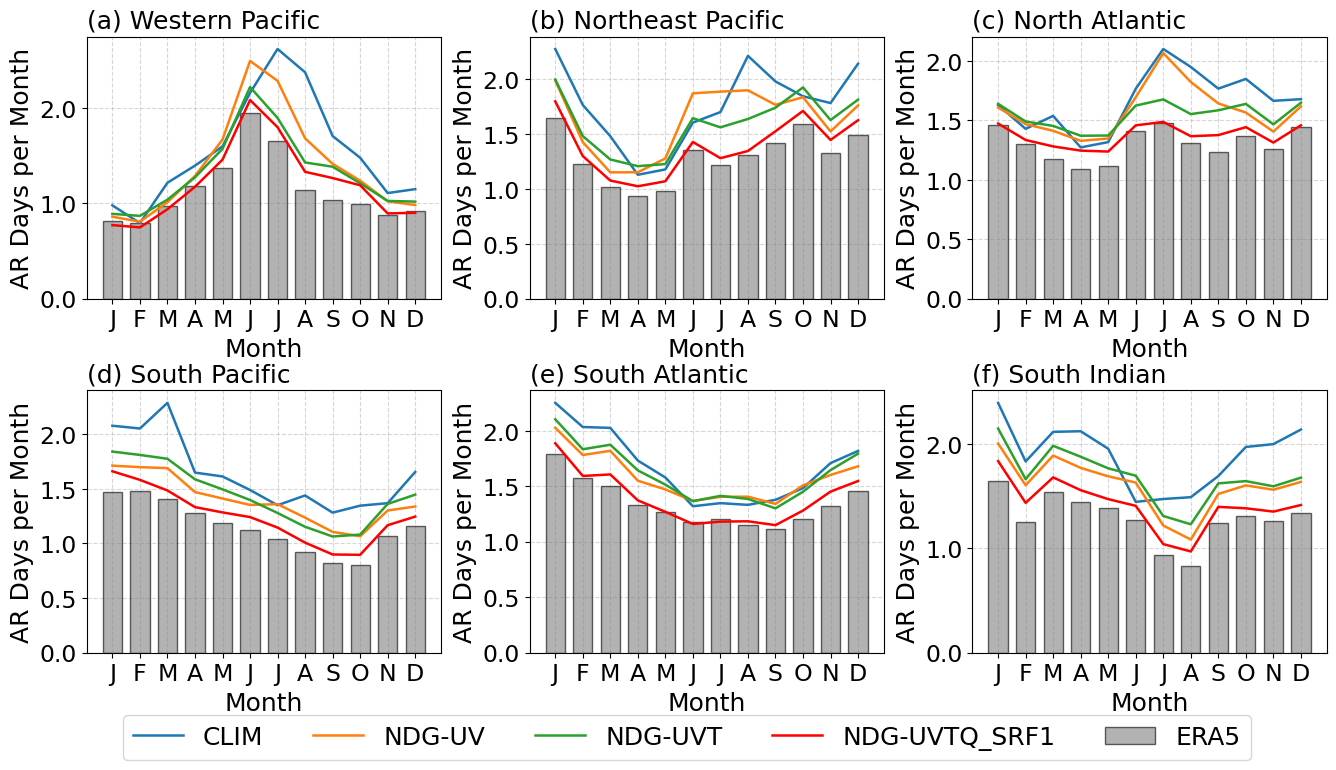

In [6]:
if __name__ == "__main__":
    top_path = "/anvil/scratch/x-szhang3"
    data_path = f"{top_path}/post_data/TempestExtremes/ARs/trk_fnl"
    out_path = "/home/x-szhang3/nudging_analysis/nudging_evaluation/data/TempestExtremes/ARs/trk_fnl" 
    os.makedirs(out_path, exist_ok=True)
    
    fig_path = "./"
    
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']

    syear, eyear = 2008, 2017    
    exp_config = {
        "ERA5":        {"label": "ERA5",            "color": "gray"},
        "CLIM":        {"label": "CLIM",            "color": colors[0]},
        "NDGUV":       {"label": "NDG-UV",          "color": colors[1]},
        "NDGUVT":      {"label": "NDG-UVT",         "color": colors[2]},
        #"NDGUVTQ":     {"label": "NDG-UVTQ",        "color": colors[3]},
        "NDGUVTQ_SRF1":{"label": "NDG-UVTQ_SRF1",   "color": "red"}
    }
    label_map = {k: v["label"] for k, v in exp_config.items()}
    color_map = {k: v["color"] for k, v in exp_config.items()}
    exp_dict = {k: v["label"] for k, v in exp_config.items()}  # Optional if needed

    binary_template = "{exp}_ARS_{year}_nff.nc"
    varname = "AR_binary_tag"
    composite_vars = ["PRECT", "IVT", "TUQ", "TVQ"]
    generate_statistics = False 
    if generate_statistics: 
        for year in range(syear, eyear + 1):
            for exp in exp_dict:
                print(f"[INFO] Processing AR diagnostics for {exp}")
                print(f"  └── Year {year}")
                # Create calculator instance for this year
                calc = AROccurrenceFrequencyCalculator(
                    data_dir=os.path.join(data_path, exp),
                    file_template=binary_template.format(exp=exp, year="{}"),
                    varname=varname,
                    syear=year,
                    eyear=year
                )

                # --- AR Frequency ---
                freq_outfile = os.path.join(out_path, exp, f"{exp}_AR_frequency_{year}.nc")
                os.makedirs(os.path.dirname(freq_outfile), exist_ok=True)
                calc.process_single_year(year, freq_outfile)

                # --- AR Composites ---
                for v in composite_vars:
                    print(f"    └── Composite for {v}")
                    comp_outfile = os.path.join(out_path, exp, f"{exp}_AR_composite_{v}_{year}.nc")
                    os.makedirs(os.path.dirname(comp_outfile), exist_ok=True)
                    calc.compute_composited_means(year=year, varname=v, varsub = "ARS", output_path=comp_outfile)

            print(f"[DONE] Finished {exp}")

        print("[ALL DONE] AR frequency and compositing complete.")
    
    # === AR Occurrence Frequency Plot ===
    obs_label = "ERA5"
    fig_name = "Figure_11.pdf"

    plotter = AROccurrenceFrequencyPlotter(
        data_dir=data_path,
        exp_dict=exp_config,  # Or just keys if needed
        syear=syear,
        eyear=eyear,
        obs_label="ERA5",
        label_map=label_map,
        color_map=color_map
    )

    # Optional: remove OBS from model rows if needed
    plotter.experiments = [exp for exp in exp_dict if exp != obs_label]

    ar_basin_dict = {
        "Western Pacific":    (0, 45, 120, 180),
        "Northeast Pacific":  (20, 60, 180, 240),
        "North Atlantic":     (20, 60, 270, 330),
        "South Pacific":      (-60, -20, 160, 240),
        "South Atlantic":     (-60, -20, 300, 360),
        "South Indian":       (-50, -20, 40, 120)
    }

    if fig_name is not None:
        save_path = os.path.join(fig_path,fig_name)
    else:
        save_path =  os.path.join(fig_path,f"figure_ar_annual_cycle_basins_{syear}_{eyear}.pdf")
        
    plotter.plot_annual_cycle_by_basin(
        region_dict=ar_basin_dict,
        return_percent=False,
        figsize=(16, 8),
        fontz = 18, 
        save_path= save_path
    )

[INFO] Loaded 10 years for ERA5
[INFO] Loaded 10 years for ERA5
[INFO] Loaded 10 years for CLIM
[INFO] Loaded 10 years for NDGUV
[INFO] Loaded 10 years for NDGUVT
[INFO] Loaded 10 years for NDGUVTQ_SRF1
[SAVED] ./Figure_C6.pdf


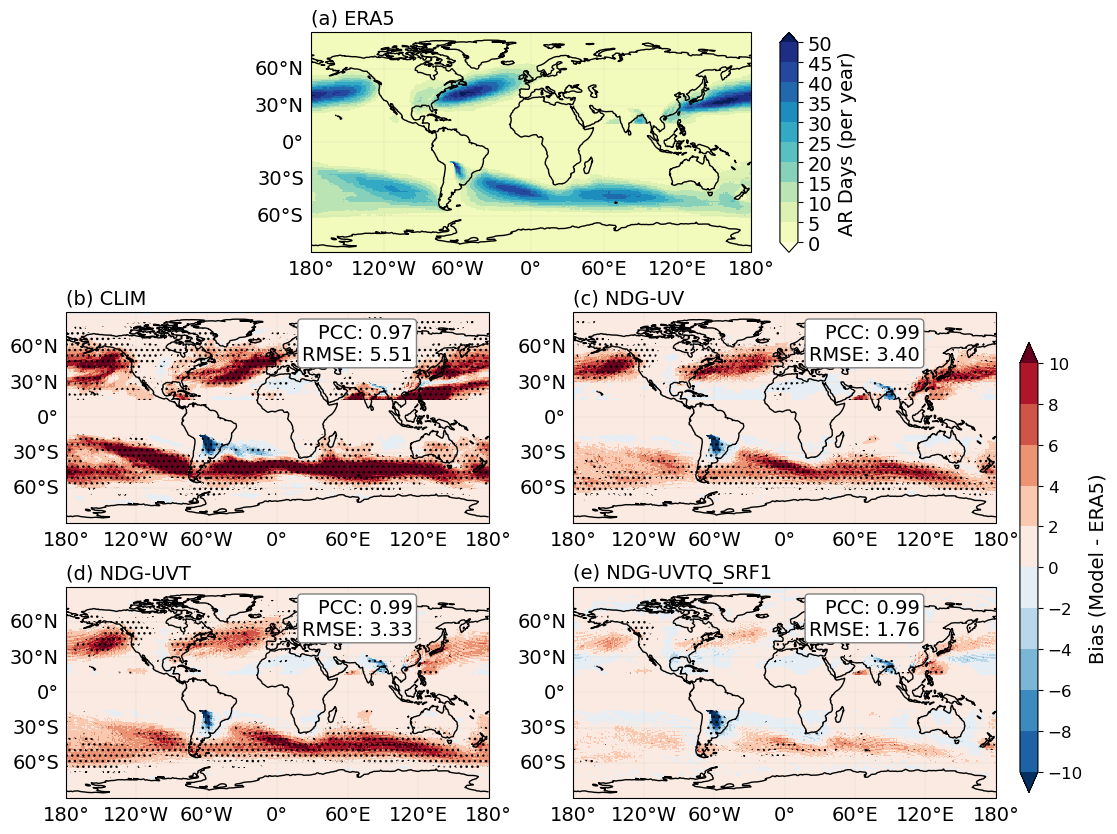

In [7]:
if __name__ == "__main__":
    top_path = "/anvil/scratch/x-szhang3"
    data_path = f"{top_path}/post_data/TempestExtremes/ARs/trk_fnl"
    out_path = "/home/x-szhang3/nudging_analysis/nudging_evaluation/data/TempestExtremes/ARs/trk_fnl" 
    os.makedirs(out_path, exist_ok=True)
    
    fig_path = "./"
    
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']

    syear, eyear = 2008, 2017    
    exp_config = {
        "ERA5":        {"label": "ERA5",            "color": "gray"},
        "CLIM":        {"label": "CLIM",            "color": colors[0]},
        "NDGUV":       {"label": "NDG-UV",          "color": colors[1]},
        "NDGUVT":      {"label": "NDG-UVT",         "color": colors[2]},
        #"NDGUVTQ":     {"label": "NDG-UVTQ",        "color": colors[3]},
        "NDGUVTQ_SRF1":{"label": "NDG-UVTQ_SRF1",   "color": "red"}
    }
    label_map = {k: v["label"] for k, v in exp_config.items()}
    color_map = {k: v["color"] for k, v in exp_config.items()}
    exp_dict = {k: v["label"] for k, v in exp_config.items()}  # Optional if needed

    binary_template = "{exp}_ARS_{year}_nff.nc"
    varname = "AR_binary_tag"
    composite_vars = ["PRECT", "IVT", "TUQ", "TVQ"]
    generate_statistics = False 
    if generate_statistics: 
        for year in range(syear, eyear + 1):
            for exp in exp_dict:
                print(f"[INFO] Processing AR diagnostics for {exp}")
                print(f"  └── Year {year}")
                # Create calculator instance for this year
                calc = AROccurrenceFrequencyCalculator(
                    data_dir=os.path.join(data_path, exp),
                    file_template=binary_template.format(exp=exp, year="{}"),
                    varname=varname,
                    syear=year,
                    eyear=year
                )

                # --- AR Frequency ---
                freq_outfile = os.path.join(out_path, exp, f"{exp}_AR_frequency_{year}.nc")
                os.makedirs(os.path.dirname(freq_outfile), exist_ok=True)
                calc.process_single_year(year, freq_outfile)

                # --- AR Composites ---
                for v in composite_vars:
                    print(f"    └── Composite for {v}")
                    comp_outfile = os.path.join(out_path, exp, f"{exp}_AR_composite_{v}_{year}.nc")
                    os.makedirs(os.path.dirname(comp_outfile), exist_ok=True)
                    calc.compute_composited_means(year=year, varname=v, varsub = "ARS", output_path=comp_outfile)

            print(f"[DONE] Finished {exp}")

        print("[ALL DONE] AR frequency and compositing complete.")
    
    # === AR Occurrence Frequency Plot ===
    obs_label = "ERA5"
    fig_name = "Figure_C6.pdf"

    plotter = AROccurrenceFrequencyPlotter(
        data_dir=data_path,
        exp_dict=exp_config,  # Or just keys if needed
        syear=syear,
        eyear=eyear,
        obs_label="ERA5",
        label_map=label_map,
        color_map=color_map
    )

    # Optional: remove OBS from model rows if needed
    plotter.experiments = [exp for exp in exp_dict if exp != obs_label]

    ar_basin_dict = {
        "Western Pacific":    (0, 45, 120, 180),
        "Northeast Pacific":  (20, 60, 180, 240),
        "North Atlantic":     (20, 60, 270, 330),
        "South Pacific":      (-60, -20, 160, 240),
        "South Atlantic":     (-60, -20, 300, 360),
        "South Indian":       (-50, -20, 40, 120)
    }
    
    clevels_raw = np.linspace(0, 50, 11)       # For ERA5 raw frequency
    clevels_bias = np.linspace(-10, 10, 11)   # For bias maps (model - ERA5)

    if fig_name is not None:
        save_path = os.path.join(fig_path,fig_name)
    else:
        save_path =  os.path.join(fig_path,f"figure_ar_frequency_glb_{syear}_{eyear}.pdf")
        
    plotter.plot(
        cmap_raw="YlGnBu",                     # For raw climatology (ERA5)
        clevels_raw=clevels_raw,
        cticks_raw=clevels_raw,
        cmap_bias="RdBu_r",                    # For biases (model - ERA5)
        clevels_bias=clevels_bias,
        cticks_bias=clevels_bias,
        figsize=(12, 10),
        fontz=14,
        hspace=0.25,
        wspace=0.2,
        save_path=save_path
    )